In [1]:
import scanpy as sc
import pandas as pd 
import numpy as np
import os
import re
import glob
import scipy as sp
from scipy import sparse
import matplotlib
from matplotlib import rcParams
from matplotlib import colors
import matplotlib.pyplot as plt

In [34]:
sample_names = [
    "GSM7110543_1216_Dg", "GSM7110544_1216_MRD", "GSM7110545_1216_R",
    "GSM7110546_1886_Dg", "GSM7110547_1886_MRD", "GSM7110548_1886_R",
    "GSM7110549_3822_Dg", "GSM7110550_3822_R", "GSM7110551_3853_Dg",
    "GSM7110552_3853_R", "GSM7110553_3904_Dg", "GSM7110554_3904_MRD",
    "GSM7110555_3904_R", "GSM7110556_40389_Dg", "GSM7110557_40389_MRD",
    "GSM7110558_40389_R", "GSM7110559_4978_Dg", "GSM7110560_4978_MRD",
    "GSM7110561_4978_R", "GSM7110562_5143_Dg", "GSM7110563_5143_R",
    "GSM7110564_5750_Dg", "GSM7110565_5750_MRD", "GSM7110566_5750_R",
    "GSM7110567_6323_Dg", "GSM7110568_6323_MRD", "GSM7110569_6323_R",
    "GSM7110570_6323_R2"
]

In [36]:
adatas = []
for i in range(0, len(sample_names)):
    data = pd.read_csv(f'../../../datasets/nuig/{sample_names[i]}_count_mat.txt', sep = '\t', index_col = 0)
    meta = pd.read_csv(f'../../../datasets/nuig/{sample_names[i]}_meta.txt', sep = '\t', index_col = 0)
    adata_ = sc.AnnData(X = data, obs = meta)
    adatas.append(adata_)  

In [37]:
for i in range(0, len(sample_names)):
    tmp = sample_names[i].split('_')
    adatas[i].obs['sample'] = tmp[0] + '_' + tmp[1]

In [38]:
adata_merge = adatas[0].concatenate(adatas[1:], batch_key='sample_ID')

C:\Users\User\AppData\Local\Temp\ipykernel_10244\1454997261.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merge = adatas[0].concatenate(adatas[1:], batch_key='sample_ID')


In [39]:
adata_merge.obs['dataset'] = 'ennis'

In [40]:
adata_merge.X = sparse.csr_matrix(adata_merge.X).astype(dtype='float32')
adata_merge.layers['counts'] = adata_merge.X
sc.pp.normalize_per_cell(adata_merge, counts_per_cell_after=1e4)
sc.pp.log1p(adata_merge)

In [41]:
adata_merge.obs['CellType'] = adata_merge.obs['celltype'].copy()
del adata_merge.obs['celltype']

In [42]:
# adata_merge.write('../data/nuig/ennis_with_label.h5ad')

In [43]:
adata_merge.write('../../../datasets/nuig/ennis.h5ad')

In [2]:
# read in data and labels
adata = sc.read('../../../datasets/nuig/ennis.h5ad')
labs = pd.read_csv('../../../datasets/nuig/ennis_cell_labels.csv', sep='\t')
adata.obs['celltype'] = labs['label']

In [45]:
adata

AnnData object with n_obs × n_vars = 111347 × 36601
    obs: 'donor', 'timepoint', 'sample', 'sample_ID', 'dataset', 'n_counts', 'CellType', 'celltype'
    uns: 'log1p'
    layers: 'counts'

c:\Users\User\Desktop\MscThesis\venv\lib\site-packages\scanpy\preprocessing\_pca.py:374: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


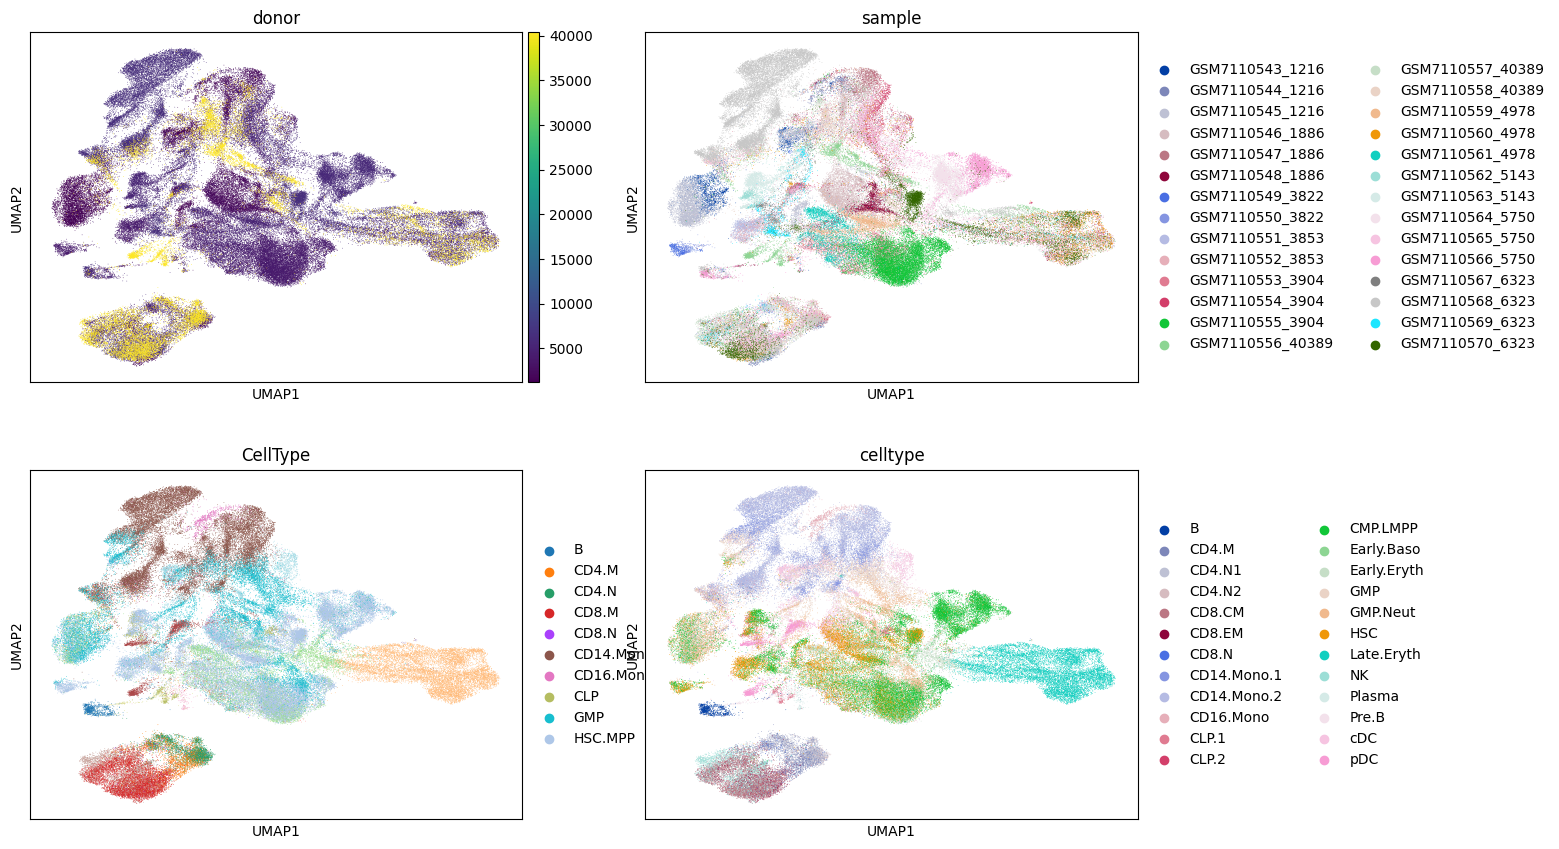

In [46]:
# visualise cells
adata.X = sp.sparse.csr_matrix(adata.X) # need to convert to sparse matrix because it will throw errors downstream
sc.pp.highly_variable_genes(adata, n_top_genes=4000)
sc.pp.pca(adata, n_comps=50, use_highly_variable=True, svd_solver='arpack')
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(adata, color=['donor', 'sample', 'CellType', 'celltype'], ncols=2)

In [47]:
adata.obs['celltype'].value_counts()

celltype
CMP.LMPP       19854
CD14.Mono.2    14566
HSC            12028
Late.Eryth     10211
GMP             7760
GMP.Neut        7581
Early.Eryth     7352
CD8.CM          6028
cDC             4352
CD14.Mono.1     4009
NK              3154
CD4.M           2557
CD4.N1          2242
pDC             1992
CD16.Mono       1476
Early.Baso      1281
CD8.EM          1179
CLP.1           1081
B                898
Pre.B            654
CD4.N2           559
Plasma           245
CD8.N            175
CLP.2            113
Name: count, dtype: int64

In [48]:
adata.obs['CellType'].value_counts()

CellType
HSC.MPP           31299
CD14.Mono         18951
GMP               16154
Late.Eryth        10184
MEP                9033
CD8.M              7235
cDC                3170
NK                 3167
CD4.N              2836
CD4.M              2701
pDC                2008
CD16.Mono          1504
CLP                1141
B                   876
Pre.B               587
Plasma              249
CD8.N               166
Megakaryocytes       49
Mesenchymal          37
Name: count, dtype: int64

In [4]:
adata.write('../../../datasets/nuig/ennis.h5ad')